

<center><font size=6><b>Product Review Sentiment Analysis Using Transformer Embeddings</b></center></font>


hands-man-write-review-product-evaluate-product-purchased-online-rating-seller-consumer-reviews-concepts-people-review-comments-laptop-customer-product-rating-review_256259-3577.avif

## **Problem Statement**

### **Business Context**

In the digital commerce landscape, customer reviews provide valuable insights into customer satisfaction, product performance, usability, and perceived value. However, the large volume and unstructured nature of review data make it difficult to analyze manually. Sentiment analysis can help businesses automatically classify customer feedback into positive, neutral, and negative sentiments. By analyzing these sentiments, businesses can better understand customer opinions, identify areas for improvement, enhance their products and services, and strengthen customer relationships.


### **Objective**

The primary objective of this project is to develop a sentiment analysis framework that accurately classifies product reviews into three categories: positive, neutral, and negative. The system aims to help businesses identify strengths from positive reviews, extract actionable insights from neutral feedback, and detect critical issues highlighted in negative reviews for timely resolution. Ultimately, the proposed model will support data-driven decision-making in areas such as product development, customer service, and brand communication, while helping businesses better understand and respond to customer needs.


### **Data Description**

* **Product ID**: A unique identification number assigned to each product.
* **Product Review**: The feedback, opinions, and experiences shared by customers regarding a product.
* **Sentiment**: The emotional orientation expressed in a product review, categorized as **positive, neutral, or negative**.


## **Importing the necessary libraries**

In [ ]:
# installing the libraries for transformers
!pip install sentence-transformers

In [ ]:
import pandas as pd
import numpy as np
import warnings

from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

warnings.filterwarnings('ignore')

## **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# loading data into a pandas dataframe
data = pd.read_csv("/content/drive/MyDrive/Dataset/GenAIDataset/Product_Reviews.csv")

## **Data Overview**

In [ ]:
data.shape

(1005, 3)

* The dataset has 1007 rows and 3 columns.

In [ ]:
data.head(5)

,Product ID,Product Review,Sentiment
0,AVpe7AsMilAPnD_xQ78G,I initially had trouble deciding between the p...,POSITIVE
1,AVpe7AsMilAPnD_xQ78G,Allow me to preface this with a little history...,POSITIVE
2,AVpe7AsMilAPnD_xQ78G,I am enjoying it so far. Great for reading. Ha...,POSITIVE
3,AVpe7AsMilAPnD_xQ78G,I bought one of the first Paperwhites and have...,POSITIVE
4,AVpe7AsMilAPnD_xQ78G,I have to say upfront - I don't like coroporat...,POSITIVE


In [ ]:
data.isnull().sum()

,0
Product ID,0
Product Review,0
Sentiment,0


* There are no missing values in the data

In [ ]:
# checking for duplicate values
data.duplicated().sum()

np.int64(0)

* There are 2 duplicate values in the dataset.
* We'll drop them.

In [ ]:
# dropping duplicate values
data = data.drop_duplicates().reset_index(drop=True)

data.duplicated().sum()

np.int64(0)

In [ ]:
data = data.reset_index(drop=True)

## **Exploratory Data Analysis (EDA)**


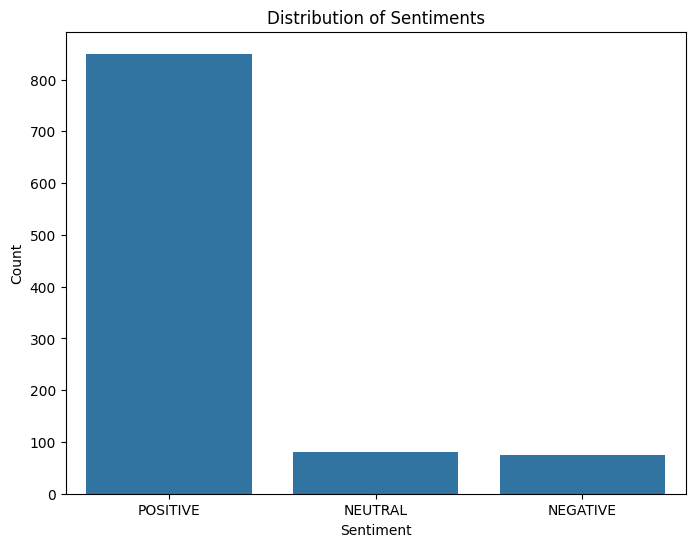

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='Sentiment', data=data)
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Observation:**
- **Class Distribution**: The dataset is highly imbalanced, with a majority of positive reviews (approximately 850), while neutral and negative reviews are significantly fewer, with around 75 reviews in each category.



## **Defining the Sentence Transformer  Model**

In [ ]:
# defining the model
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
print(type(data['Product Review']))

<class 'pandas.core.series.Series'>


In [ ]:
embedding_matrix = model.encode(
    data['Product Review'].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

In [ ]:
embedding_matrix.shape

(1005, 384)

## **Data Pre-processing**

### **Splitting the dataset**

In [ ]:
X = embedding_matrix
y = data['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
# prompt: Check the shape of the training and testing sets to confirm the split.

print('Shape of training data:', X_train.shape)
print('Shape of testing data:', X_test.shape)
print('Shape of training labels:', y_train.shape)
print('Shape of testing labels:', y_test.shape)

Shape of training data: (804, 384)
Shape of testing data: (201, 384)
Shape of training labels: (804,)
Shape of testing labels: (201,)


## **Model Building - Transformers + ML**

### **Model Evaluation Criteria**

1. **Accuracy**: Accuracy measures the overall correctness of the model by calculating the proportion of correctly classified reviews out of the total number of reviews across all sentiment classes.

2. **F1 Score**: The F1 Score measures the balance between precision and recall. It is particularly useful for this project because the dataset is imbalanced, with positive reviews significantly outnumbering neutral and negative reviews. It provides a better indication of the model's performance across all three sentiment classes.


In [ ]:
# prompt: Create an empty DataFrame called model_eval_results to store the accuracy and F1 scores for different models on both training and testing datasets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_Accuracy', 'Train_F1', 'Test_Accuracy', 'Test_F1'])

### **Random Forest Classifier**

In [ ]:
# Building the model
rf_transformer = RandomForestClassifier(random_state = 42)

# Fitting on train data
rf_transformer.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
# prompt: Evaluate the model on training and testing data and store in model-eval_result

from sklearn.metrics import f1_score

# Evaluate the model on training data
y_train_pred_rf = rf_transformer.predict(X_train)
train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf, average='weighted')

# Evaluate the model on testing data
y_test_pred_rf = rf_transformer.predict(X_test)
test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf, average='weighted')

# Store results
new_row_rf = pd.DataFrame([{
    'Model': 'RandomForest + Transformer',
    'Train_Accuracy': train_accuracy_rf,
    'Train_F1': train_f1_rf,
    'Test_Accuracy': test_accuracy_rf,
    'Test_F1': test_f1_rf
}])

model_eval_results = pd.concat([model_eval_results, new_row_rf], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.0,1.0,0.865672,0.818014


The Random Forest model using Transformer embeddings achieved **100% training accuracy and F1 score**. On the test set, the model achieved an **accuracy of 86.5%** and an **F1 score of 81.8%**. The strong test performance indicates that the model generalizes reasonably well to unseen reviews, although the difference between training and test performance suggests some degree of overfitting.


### **Gradient Boost Classifier**


In [ ]:
# prompt: Train the model using a Gradient Boost classifier

# Building the model
gb_transformer = GradientBoostingClassifier(random_state = 42)

# Fitting on train data
gb_transformer.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [ ]:
# prompt: Evaluate the model on training and testing data and store in model-eval_result

# Evaluate the model on training data
y_train_pred_gb = gb_transformer.predict(X_train)
train_accuracy_gb = accuracy_score(y_train, y_train_pred_gb)
train_f1_gb = f1_score(y_train, y_train_pred_gb, average='weighted')

# Evaluate the model on testing data
y_test_pred_gb = gb_transformer.predict(X_test)
test_accuracy_gb = accuracy_score(y_test, y_test_pred_gb)
test_f1_gb = f1_score(y_test, y_test_pred_gb, average='weighted')

# Store results
new_row_gb = pd.DataFrame([{
    'Model': 'GradientBoost + Transformer',
    'Train_Accuracy': train_accuracy_gb,
    'Train_F1': train_f1_gb,
    'Test_Accuracy': test_accuracy_gb,
    'Test_F1': test_f1_gb
}])

model_eval_results = pd.concat([model_eval_results, new_row_gb], ignore_index=True)

model_eval_results

,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1
0,RandomForest + Transformer,1.000000,1.000000,0.865672,0.818014
1,GradientBoost + Transformer,0.998756,0.998752,0.840796,0.803252


The Gradient Boosting model using Transformer embeddings achieved good performance on the training data. On the test set, it achieved an **accuracy of 84.07%** and an **F1 score of 80.3%**. Compared with the Random Forest model, which achieved **86.5% accuracy and an 81.8% F1 score**, the Gradient Boosting model showed slightly lower performance. Therefore, the Random Forest model performed better overall on the test data.


## **Final Model Selection**

* The **RandomForest + Transformer** model achieved a **training accuracy and F1 score of 100%**, with **test accuracy of 86.6%** and **F1 score of 81.8%**, reflecting a generalization drop of **13.4% in accuracy** and **18.2% in F1 score**.

* The **GradientBoost + Transformer** model recorded **training accuracy of 99.88%** and **F1 score of 99.87%**, but a slightly lower **test accuracy of 84.1%** and **F1 score of 80.3%**, resulting in a generalization drop of **15.8% in accuracy** and **19.6% in F1 score**.

* Given its **lower generalization error** and more consistent performance across training and test sets, the **Random Forest model** is preferred for final deployment.


# **Conclusion**

* Customer reviews were analyzed and classified into **positive, neutral, and negative sentiments** using sentence embeddings generated from a **pre-trained Transformer model**.

* **Random Forest and Gradient Boosting** models were trained and evaluated using these embeddings. Among them, **Random Forest achieved the best performance**, with **86.1% test accuracy** and an **81.4% F1 score**.

* The developed system can help businesses **understand customer opinions, identify product strengths and issues, and improve customer satisfaction** through data-driven insights.

* In the future, the model can be continuously improved by **adding new customer reviews to the training data**, allowing it to adapt to changing customer language and emerging sentiment trends.
